# VQE Figures for Slides

Experimental notebook to generate figures from the latest VQE/FCI caches. Figures are saved in `outputs/figures/slides/`.


## Setup

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from qiskit.primitives import StatevectorEstimator

from src.vqe.grid_search import run_vqe_grid_search
from src.vqe.molecular_system import statevector_grid_systems
from src.visualization.vqe_plots import (
    best_vqe_by_point,
    chemical_accuracy_config_table,
    ensure_figures_dir,
    load_latest_fci_curves,
    load_latest_vqe_results,
    plot_ansatz_comparison,
    plot_chemical_accuracy_rate,
    plot_dissociation_curve,
    plot_optimizer_comparison,
    plot_runtime_by_configuration,
    save_figure,
)

pd.set_option("display.max_columns", None)
output_dir = ensure_figures_dir()
seed = 137

## Load Latest Data


In [2]:
vqe_df = load_latest_vqe_results()
fci_df = load_latest_fci_curves(strategy="densest")

print(f"VQE rows: {len(vqe_df)}")
print(f"FCI/CASCI rows: {len(fci_df)}")
vqe_df

VQE rows: 1032
FCI/CASCI rows: 1548


,molecule,run_label,noise_source,backend_name,shots,basis,distance,mapper,ansatz,reps,optimizer,max_iter,seed,active_space,active_orbitals,freeze_core,energy,reference_energy,reference_method,fci_energy,abs_error_hartree,abs_error_kcal_mol,within_chemical_accuracy,vqe_raw_energy,eval_count,success,error,error_type,num_qubits,num_terms,constant_energy,setup_hamiltonian_s,vqe_execution_s,total_experiment_s,source_path,source_mtime
0,BeH2,statevector,NaN,NaN,NaN,sto-3g,0.5,jw,real_amplitudes,1,cobyla,100,137,"[4, 4]","[0, 1, 2, 3]",True,-13.521877,-13.667143,CASCI,-13.667143,1.452666e-01,91.156119,False,-4.860621,100,True,NaN,NaN,8,61,-8.661256,0.430853,1.552169,1.993080,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.780078e+09
1,BeH2,statevector,NaN,NaN,NaN,sto-3g,0.5,jw,real_amplitudes,1,slsqp,100,137,"[4, 4]","[0, 1, 2, 3]",True,-13.460636,-13.667143,CASCI,-13.667143,2.065075e-01,129.585303,False,-4.799380,919,True,NaN,NaN,8,61,-8.661256,0.479199,10.035628,10.517597,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.780078e+09
2,BeH2,statevector,NaN,NaN,NaN,sto-3g,0.5,jw,real_amplitudes,1,spsa,100,137,"[4, 4]","[0, 1, 2, 3]",True,-13.453005,-13.667143,CASCI,-13.667143,2.141378e-01,134.373420,False,-4.791750,200,True,NaN,NaN,8,61,-8.661256,0.388868,2.113073,2.504785,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.780078e+09
3,BeH2,statevector,NaN,NaN,NaN,sto-3g,0.5,jw,real_amplitudes,2,cobyla,100,137,"[4, 4]","[0, 1, 2, 3]",True,-13.460477,-13.667143,CASCI,-13.667143,2.066664e-01,129.685048,False,-4.799221,100,True,NaN,NaN,8,61,-8.661256,0.378412,1.359170,1.742216,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.780078e+09
4,BeH2,statevector,NaN,NaN,NaN,sto-3g,0.5,jw,real_amplitudes,2,slsqp,100,137,"[4, 4]","[0, 1, 2, 3]",True,-13.646139,-13.667143,CASCI,-13.667143,2.100429e-02,13.180381,False,-4.984883,1629,True,NaN,NaN,8,61,-8.661256,0.382772,20.701916,21.087535,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.780078e+09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1027,LiH,statevector_physical_ansatz,NaN,NaN,NaN,sto-3g,2.8,jw,puccsd,1,slsqp,250,137,"[2, 3]","[0, 1, 2]",True,-7.742346,-7.742346,CASCI,-7.742346,9.164975e-09,0.000006,True,-0.796096,71,True,NaN,NaN,6,62,-6.946250,0.274357,10.865508,11.150780,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.779063e+09
1028,LiH,statevector_physical_ansatz,NaN,NaN,NaN,sto-3g,3.2,jw,uccsd,1,cobyla,250,137,"[2, 3]","[0, 1, 2]",True,-7.718400,-7.719239,CASCI,-7.719239,8.393723e-04,0.526714,True,-0.748475,250,True,NaN,NaN,6,62,-6.969925,0.285291,50.560032,50.856781,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.779063e+09
1029,LiH,statevector_physical_ansatz,NaN,NaN,NaN,sto-3g,3.2,jw,uccsd,1,slsqp,250,137,"[2, 3]","[0, 1, 2]",True,-7.718479,-7.719239,CASCI,-7.719239,7.604564e-04,0.477193,True,-0.748554,210,True,NaN,NaN,6,62,-6.969925,0.243561,42.705868,42.961120,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.779063e+09
1030,LiH,statevector_physical_ansatz,NaN,NaN,NaN,sto-3g,3.2,jw,puccsd,1,cobyla,250,137,"[2, 3]","[0, 1, 2]",True,-7.719239,-7.719239,CASCI,-7.719239,2.293589e-09,0.000001,True,-0.749314,116,True,NaN,NaN,6,62,-6.969925,0.239748,18.112923,18.364924,/mnt/c/Users/yannk/PycharmProjects/vqe-quantum...,1.779063e+09


## Best Results by Point


In [3]:
best_df = best_vqe_by_point(vqe_df)
best_df[[
    "molecule",
    "basis",
    "distance",
    "ansatz",
    "reps",
    "optimizer",
    "energy",
    "reference_energy",
    "abs_error_kcal_mol",
    "within_chemical_accuracy",
    "total_experiment_s",
]].sort_values(["molecule", "basis", "distance"])

,molecule,basis,distance,ansatz,reps,optimizer,energy,reference_energy,abs_error_kcal_mol,within_chemical_accuracy,total_experiment_s
0,BeH2,sto-3g,0.5000,efficient_su2,2,slsqp,-13.646157,-13.667143,1.316877e+01,False,30.892546
1,BeH2,sto-3g,0.8000,real_amplitudes,2,slsqp,-15.150750,-15.155330,2.873746e+00,False,26.117320
2,BeH2,sto-3g,1.1000,real_amplitudes,2,slsqp,-15.522005,-15.528633,4.158760e+00,False,12.246482
3,BeH2,sto-3g,1.4000,efficient_su2,2,slsqp,-15.552459,-15.558237,3.625749e+00,False,17.848395
4,BeH2,sto-3g,1.7000,real_amplitudes,2,slsqp,-15.470617,-15.476334,3.587309e+00,False,9.092540
5,BeH2,sto-3g,2.0000,real_amplitudes,2,slsqp,-15.373862,-15.385345,7.205584e+00,False,28.383751
6,BeH2,sto-3g,2.3000,real_amplitudes,2,slsqp,-15.250700,-15.290260,2.482451e+01,False,28.125872
7,BeH2,sto-3g,2.6000,efficient_su2,2,slsqp,-15.217281,-15.237905,1.294150e+01,False,60.031960
8,BeH2,sto-3g,3.0000,efficient_su2,2,slsqp,-15.232623,-15.253037,1.281015e+01,False,45.371405
9,H2,6-31g,0.3500,efficient_su2,1,slsqp,-0.819156,-0.835694,1.037762e+01,False,24.393920


## Configuration DataFrame

Complete summary of `statevector` combinations. No basis is discarded: use `reached_chemical_accuracy` or `accurate_points > 0` to filter only configurations that reached chemical accuracy. The `is_best` column marks the best configuration for each molecule.


In [4]:
statevector_config_df = chemical_accuracy_config_table(vqe_df, only_accurate=False)

config_cols = [
    "molecule",
    "basis",
    "ansatz",
    "reps",
    "optimizer",
    "points",
    "accurate_points",
    "accuracy_rate",
    "reached_chemical_accuracy",
    "best_error_kcal_mol",
    "mean_error_kcal_mol",
    "median_error_kcal_mol",
    "best_distance",
    "mean_time_s",
    "rank",
    "is_best",
]

statevector_config_df[config_cols].sort_values([
    "molecule",
    "basis",
    "reached_chemical_accuracy",
    "accuracy_rate",
    "mean_error_kcal_mol",
], ascending=[True, True, False, False, True])


,molecule,basis,ansatz,reps,optimizer,points,accurate_points,accuracy_rate,reached_chemical_accuracy,best_error_kcal_mol,mean_error_kcal_mol,median_error_kcal_mol,best_distance,mean_time_s,rank,is_best
34,BeH2,sto-3g,efficient_su2,2,slsqp,9,0,0.0,False,3.594797,12.208589,12.810149,1.7000,30.677666,1,True
35,BeH2,sto-3g,real_amplitudes,2,slsqp,9,0,0.0,False,2.873746,13.119579,7.205584,0.8000,20.969614,2,False
41,BeH2,sto-3g,efficient_su2,1,slsqp,9,0,0.0,False,3.594857,21.008491,13.179890,1.7000,25.924121,3,False
60,BeH2,sto-3g,real_amplitudes,1,slsqp,9,0,0.0,False,39.763317,106.795301,84.601161,3.0000,11.446701,4,False
61,BeH2,sto-3g,real_amplitudes,1,cobyla,9,0,0.0,False,36.667557,108.524795,120.022304,1.1000,1.955807,5,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50,LiH,sto-3g,real_amplitudes,2,spsa,9,0,0.0,False,5.340678,45.528453,30.439298,1.8000,2.805784,26,False
51,LiH,sto-3g,efficient_su2,2,spsa,9,0,0.0,False,7.600978,45.863847,41.609325,1.5949,3.180671,27,False
54,LiH,sto-3g,real_amplitudes,1,spsa,9,0,0.0,False,9.659243,70.561215,69.335498,2.8000,2.466619,30,False
55,LiH,sto-3g,efficient_su2,1,cobyla,9,0,0.0,False,60.543816,83.911854,86.537193,2.8000,1.970948,31,False


In [5]:
configs_with_chemical_accuracy = statevector_config_df[
    statevector_config_df["reached_chemical_accuracy"]
].copy()

configs_with_chemical_accuracy[config_cols].sort_values([
    "molecule",
    "rank",
    "basis",
    "accuracy_rate",
], ascending=[True, True, True, False])


,molecule,basis,ansatz,reps,optimizer,points,accurate_points,accuracy_rate,reached_chemical_accuracy,best_error_kcal_mol,mean_error_kcal_mol,median_error_kcal_mol,best_distance,mean_time_s,rank,is_best
0,H2,sto-3g,puccsd,1,cobyla,9,9,1.000000,True,1.656498e-07,0.000002,0.000002,0.7350,1.642613,1,True
3,H2,sto-3g,puccsd,1,slsqp,9,9,1.000000,True,2.703609e-07,0.000039,0.000016,0.9000,1.068444,2,False
5,H2,sto-3g,uccsd,1,slsqp,9,9,1.000000,True,9.110667e-06,0.000097,0.000105,1.1000,2.762777,3,False
7,H2,sto-3g,uccsd,1,cobyla,9,9,1.000000,True,6.649386e-08,0.000443,0.000002,0.9000,5.711453,4,False
8,H2,sto-3g,efficient_su2,2,slsqp,9,9,1.000000,True,2.426643e-05,0.001653,0.000161,0.7350,6.636281,5,False
24,H2,sto-3g,efficient_su2,1,slsqp,9,3,0.333333,True,6.897711e-05,8.078585,7.636245,0.9000,2.937866,6,False
26,H2,sto-3g,real_amplitudes,1,cobyla,9,2,0.222222,True,1.397183e-01,9.854262,7.640932,1.4000,1.063703,7,False
27,H2,sto-3g,real_amplitudes,1,spsa,9,2,0.222222,True,9.384618e-02,11.925022,12.385550,1.4000,1.222145,8,False
13,Li2O_linear,6-31g,efficient_su2,2,slsqp,7,5,0.714286,True,3.996290e-03,5.017527,0.008061,1.2000,31.558044,1,True
19,Li2O_linear,sto-3g,efficient_su2,1,slsqp,7,4,0.571429,True,6.776465e-02,14.553181,0.089286,2.1000,19.372956,2,False


In [6]:
best_statevector_configs = statevector_config_df[
    statevector_config_df["is_best"]
].copy()

best_statevector_configs[config_cols].sort_values("molecule")


,molecule,basis,ansatz,reps,optimizer,points,accurate_points,accuracy_rate,reached_chemical_accuracy,best_error_kcal_mol,mean_error_kcal_mol,median_error_kcal_mol,best_distance,mean_time_s,rank,is_best
34,BeH2,sto-3g,efficient_su2,2,slsqp,9,0,0.000000,False,3.594797e+00,12.208589,12.810149,1.700,30.677666,1,True
0,H2,sto-3g,puccsd,1,cobyla,9,9,1.000000,True,1.656498e-07,0.000002,0.000002,0.735,1.642613,1,True
13,Li2O_linear,6-31g,efficient_su2,2,slsqp,7,5,0.714286,True,3.996290e-03,5.017527,0.008061,1.200,31.558044,1,True
1,LiH,sto-3g,puccsd,1,cobyla,9,9,1.000000,True,1.439248e-06,0.000005,0.000005,3.200,18.982267,1,True


## Dissociation Curves


outputs/figures/slides/dissociacao_H2_sto-3g.png


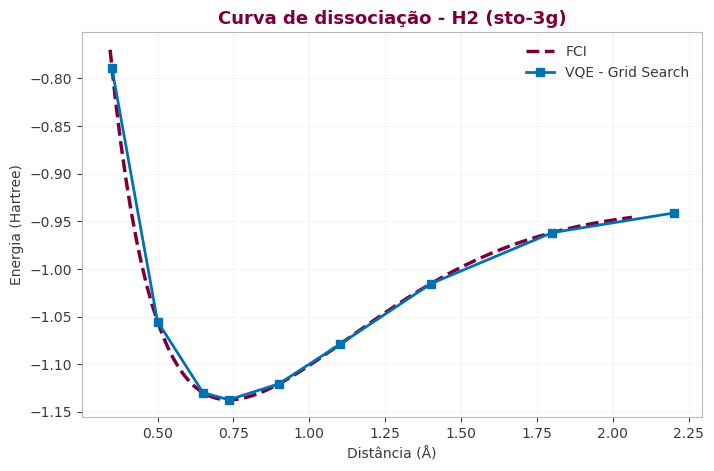

outputs/figures/slides/dissociacao_LiH_sto-3g.png


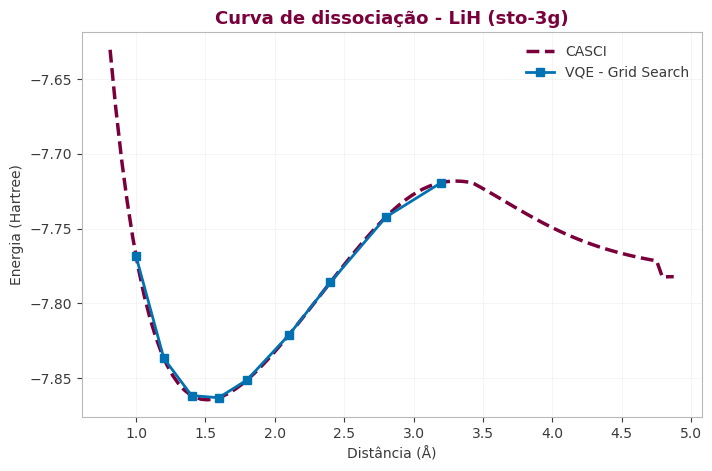

outputs/figures/slides/dissociacao_Li2O_linear_6-31g.png


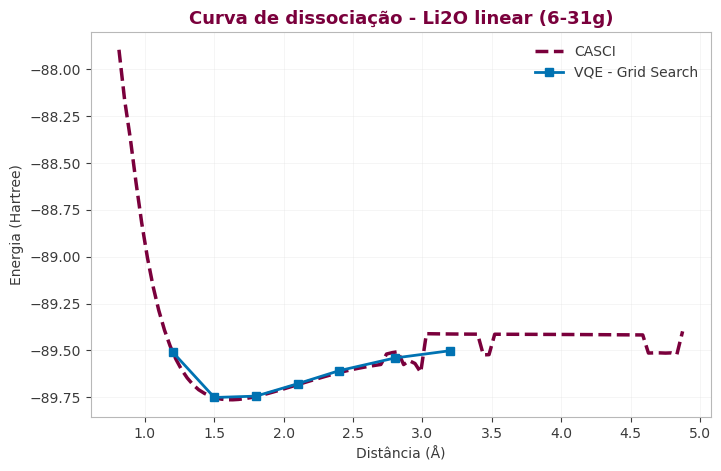

outputs/figures/slides/dissociacao_BeH2_sto-3g.png


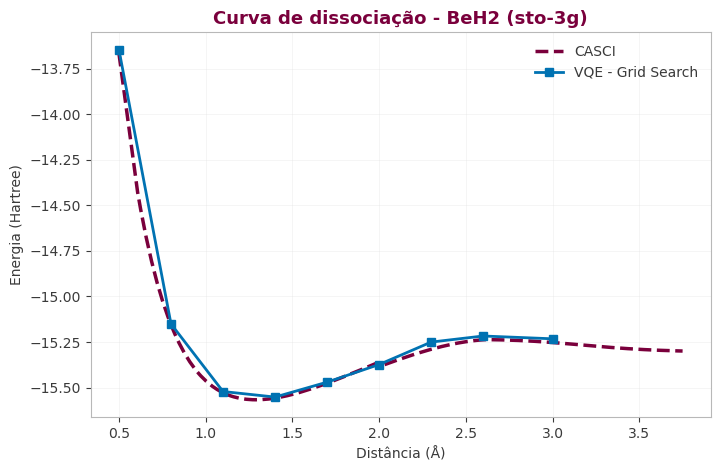

In [7]:
for molecule, basis in [
    ("H2", "sto-3g"),
    ("LiH", "sto-3g"),
    ("Li2O_linear", "6-31g"),
    ("BeH2", "sto-3g"),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_dissociation_curve(fci_df, vqe_df, molecule=molecule, basis=basis, ax=ax)
    path = save_figure(fig, output_dir, f"dissociacao_{molecule}_{basis}.png")
    print(path)
    plt.show()

## Ansatz Comparison

We fix the basis and optimizer; each line shows the best error by distance for each ansatz.


outputs/figures/slides/ansatz_H2_sto-3g_cobyla.png


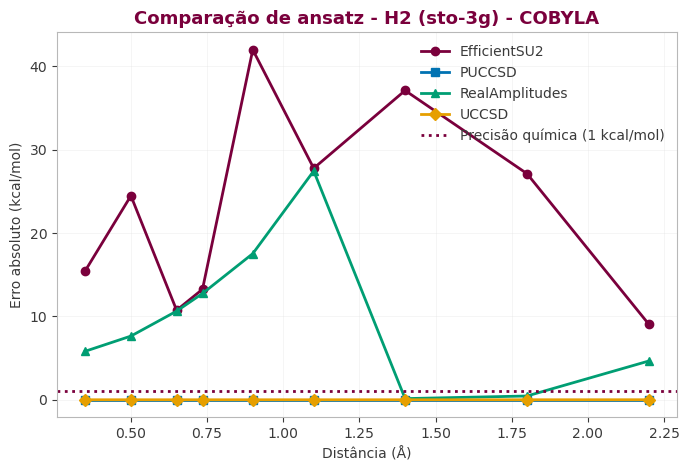

outputs/figures/slides/ansatz_LiH_sto-3g_cobyla.png


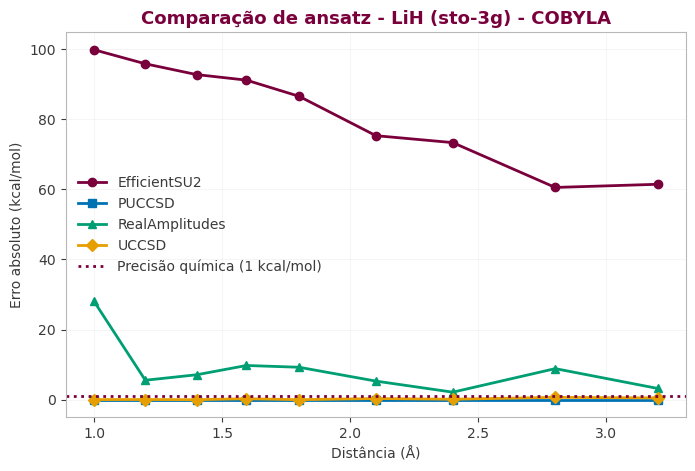

outputs/figures/slides/ansatz_Li2O_linear_6-31g_cobyla.png


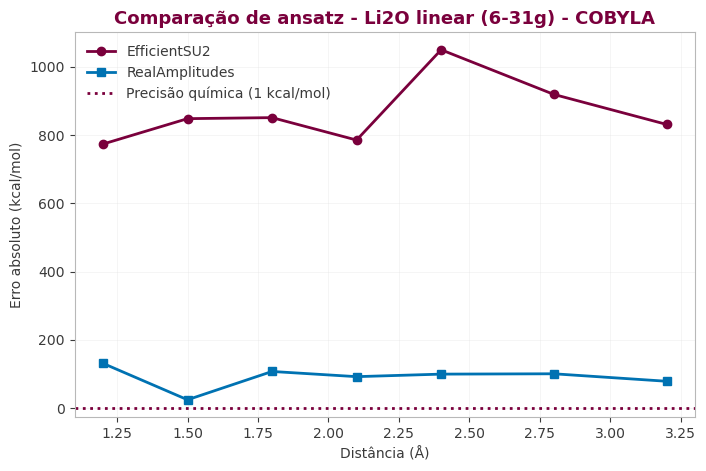

outputs/figures/slides/ansatz_BeH2_sto-3g_cobyla.png


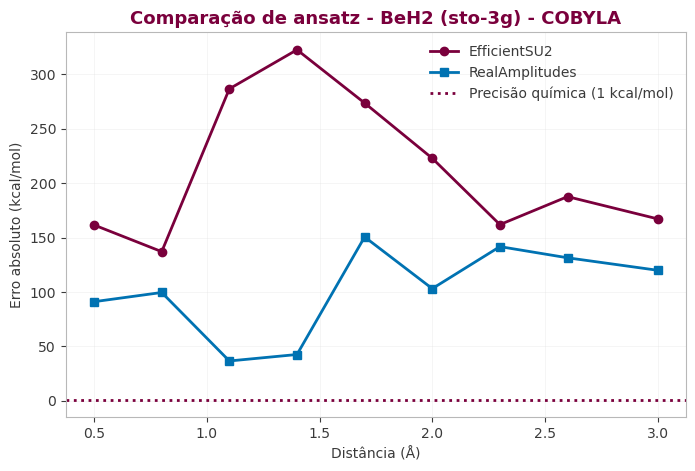

In [13]:
for molecule, basis, optimizer in [
    ("H2", "sto-3g", "cobyla"),
    ("LiH", "sto-3g", "cobyla"),
    ("Li2O_linear", "6-31g", "cobyla"),
    ("BeH2", "sto-3g", "cobyla"),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_ansatz_comparison(vqe_df, molecule=molecule, basis=basis, optimizer=optimizer, ax=ax)
    path = save_figure(fig, output_dir, f"ansatz_{molecule}_{basis}_{optimizer}.png")
    print(path)
    plt.show()

## Optimizer Comparison

We fix the molecule, basis, and ansatz; each line shows the best error by distance for each optimizer.


outputs/figures/slides/otimizadores_H2_sto-3g_efficient_su2.png


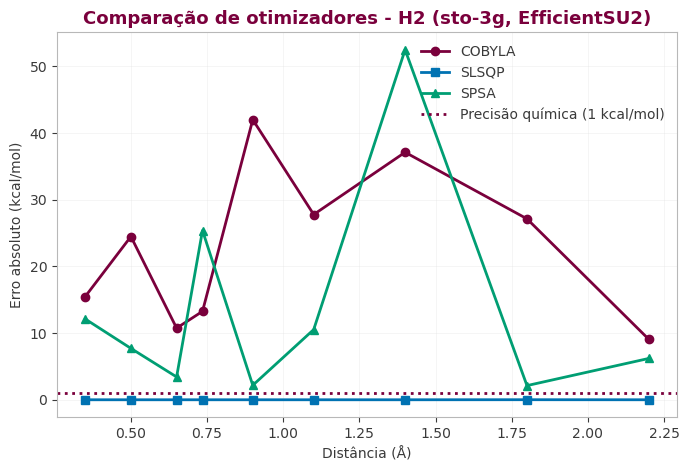

outputs/figures/slides/otimizadores_LiH_sto-3g_efficient_su2.png


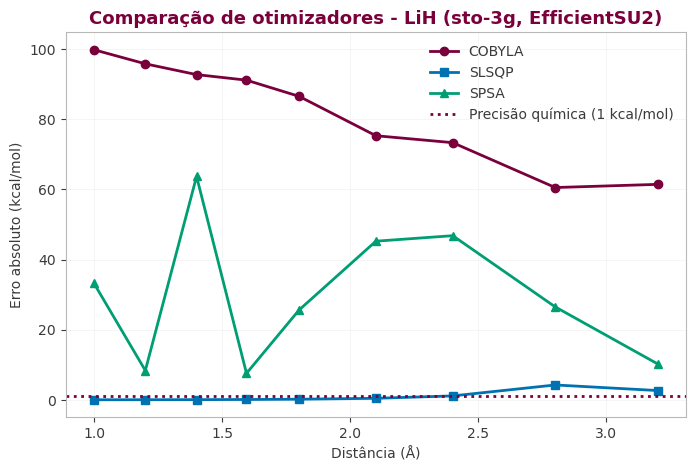

outputs/figures/slides/otimizadores_Li2O_linear_6-31g_efficient_su2.png


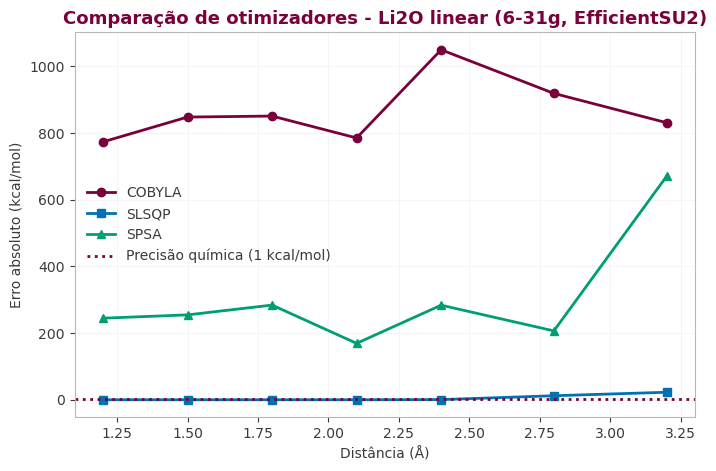

outputs/figures/slides/otimizadores_BeH2_sto-3g_efficient_su2.png


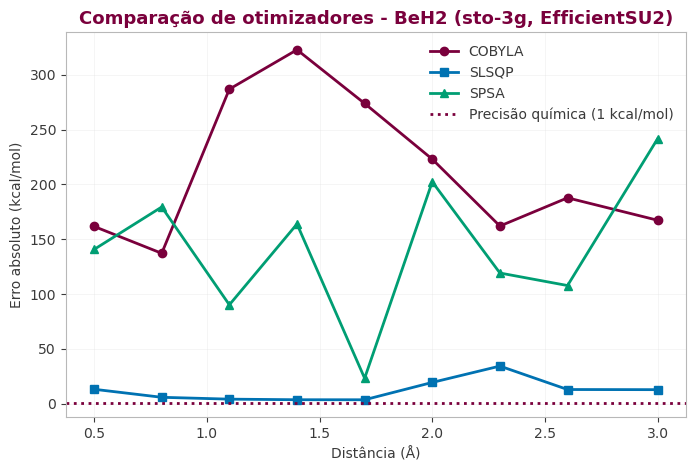

In [9]:
for molecule, basis, ansatz in [
    ("H2", "sto-3g", "efficient_su2"),
    ("LiH", "sto-3g", "efficient_su2"),
    ("Li2O_linear", "6-31g", "efficient_su2"),
    ("BeH2", "sto-3g", "efficient_su2"),
]:
    fig, ax = plt.subplots(figsize=(8, 5))
    plot_optimizer_comparison(vqe_df, molecule=molecule, basis=basis, ansatz=ansatz, ax=ax)
    path = save_figure(fig, output_dir, f"otimizadores_{molecule}_{basis}_{ansatz}.png")
    print(path)
    plt.show()

## Chemical Accuracy


outputs/figures/slides/taxa_precisao_quimica.png


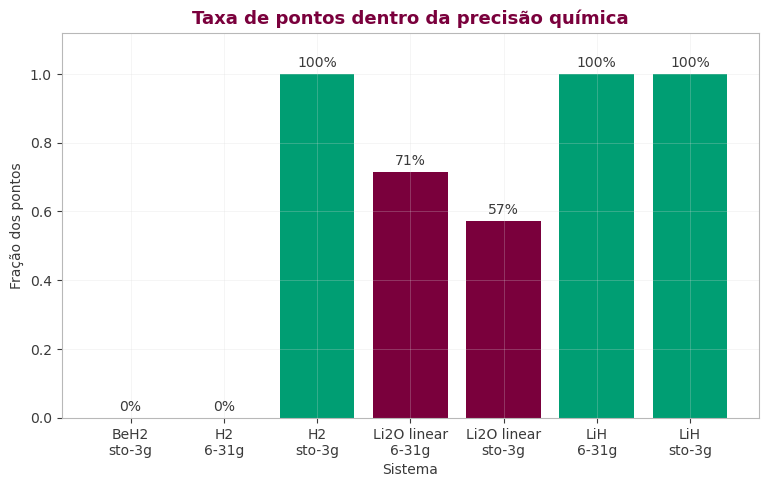

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_chemical_accuracy_rate(vqe_df, ax=ax)
path = save_figure(fig, output_dir, "taxa_precisao_quimica.png")
print(path)
plt.show()

## Runtime


outputs/figures/slides/tempo_medio_configuracao.png


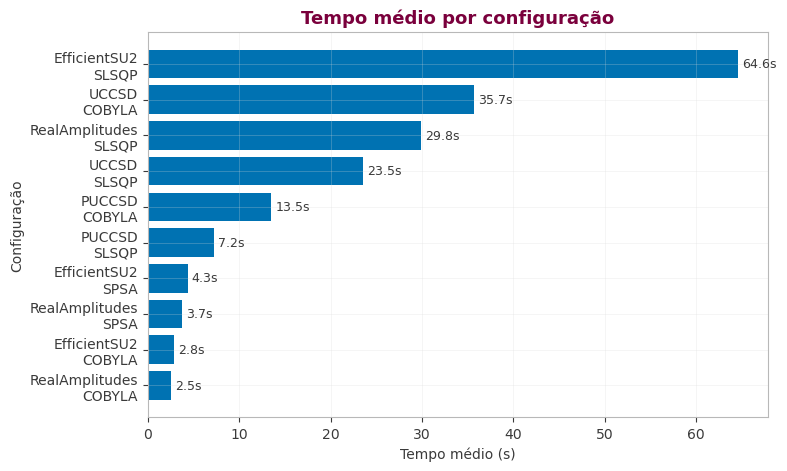

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_runtime_by_configuration(vqe_df, ax=ax)
path = save_figure(fig, output_dir, "tempo_medio_configuracao.png")
print(path)
plt.show()

## Generated Figures


In [12]:
for path in sorted(output_dir.glob("*.png")):
    print(path)

outputs/figures/slides/ansatz_BeH2_sto-3g_cobyla.png
outputs/figures/slides/ansatz_H2_sto-3g_cobyla.png
outputs/figures/slides/ansatz_Li2O_linear_6-31g_cobyla.png
outputs/figures/slides/ansatz_LiH_sto-3g_cobyla.png
outputs/figures/slides/dissociacao_BeH2_sto-3g.png
outputs/figures/slides/dissociacao_H2_sto-3g.png
outputs/figures/slides/dissociacao_Li2O_linear_6-31g.png
outputs/figures/slides/dissociacao_LiH_sto-3g.png
outputs/figures/slides/otimizadores_BeH2_sto-3g_efficient_su2.png
outputs/figures/slides/otimizadores_H2_sto-3g_efficient_su2.png
outputs/figures/slides/otimizadores_Li2O_linear_6-31g_efficient_su2.png
outputs/figures/slides/otimizadores_LiH_sto-3g_efficient_su2.png
outputs/figures/slides/taxa_precisao_quimica.png
outputs/figures/slides/tempo_medio_configuracao.png
